In [34]:
# ---------- 0. Setup ----------
import os, glob, random, warnings
import numpy as np, pandas as pd
import soundfile as sf
import librosa
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from scipy.signal import butter, sosfilt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt, seaborn as sns
 
warnings.filterwarnings("ignore")
 
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
 
SR       = 16000
DUR      = 3.0                      # seconds per training clip
N_MELS   = 128
N_MFCC   = 40
HOP      = 512
IMG      = (128, 128)               # mel resized to this before the CNN
MAX_CROPS_PER_FILE = 8              # cap so long music tracks don't dominate
CLASSES  = ["music", "noise", "speech"]      # alphabetical -> 0, 1, 2
C2I      = {c: i for i, c in enumerate(CLASSES)}
AUDIO_EXT = (".wav", ".mp3", ".flac", ".ogg", ".m4a", ".aac")

Device: cuda


In [35]:
# ---------- 1. Find the dataset root ----------
# The exact folder depth varies between Kaggle dataset uploads, so instead of
# hard-coding it we search for the directories actually named music/noise/speech.
SEARCH_ROOTS = [
    "/kaggle/input/datasets/nhattruongdev/musan-noise",   # path you gave
    "/kaggle/input/musan-noise",                          # usual Kaggle form
    "/kaggle/input",                                      # last-resort sweep
]
 
 
def find_class_dirs(roots, classes, max_depth=6):
    """Return {class_name: [dirs]} for every directory named after a class."""
    found = {c: [] for c in classes}
    for root in roots:
        if not os.path.isdir(root):
            continue
        base_depth = root.rstrip("/").count("/")
        for dirpath, dirnames, _ in os.walk(root):
            if dirpath.count("/") - base_depth > max_depth:
                dirnames[:] = []
                continue
            name = os.path.basename(dirpath).lower()
            if name in found:
                found[name].append(dirpath)
        if any(found[c] for c in classes):
            break                                   # stop at the first root that works
    return found
 
 
class_dirs = find_class_dirs(SEARCH_ROOTS, CLASSES)
for c in CLASSES:
    print(f"{c:6s}: {len(class_dirs[c])} dir(s)", class_dirs[c][:2])
 
missing = [c for c in CLASSES if not class_dirs[c]]
if missing:
    print("\n!! No directory found for:", missing)
    print("Here is what /kaggle/input actually contains — copy the right path in:")
    for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
        depth = dirpath.count("/") - 2
        if depth > 3:
            dirnames[:] = []
            continue
        print("  " * depth + os.path.basename(dirpath) + f"/  ({len(filenames)} files)")
    raise SystemExit(
        "Fix SEARCH_ROOTS above. Note: this dataset slug is 'musan-noise' — if it only "
        "ships the noise subset you also need to attach the music and speech subsets."
    )
 

music : 1 dir(s) ['/kaggle/input/datasets/nhattruongdev/musan-noise/musan/music']
noise : 1 dir(s) ['/kaggle/input/datasets/nhattruongdev/musan-noise/musan/noise']
speech: 1 dir(s) ['/kaggle/input/datasets/nhattruongdev/musan-noise/musan/speech']


In [36]:
# ---------- 2. Build the clip index (multiple crops per file) ----------
rows = []
for cls in CLASSES:
    for d in class_dirs[cls]:
        for p in glob.glob(os.path.join(d, "**", "*"), recursive=True):
            if not p.lower().endswith(AUDIO_EXT):
                continue
            try:
                info = sf.info(p)
                dur = info.frames / float(info.samplerate)
            except Exception:
                dur = DUR                                # unreadable header -> one crop
            n_crops = int(min(MAX_CROPS_PER_FILE, max(1, dur // DUR)))
            # evenly spaced, non-overlapping-ish start offsets
            usable = max(0.0, dur - DUR)
            offsets = np.linspace(0, usable, n_crops) if n_crops > 1 else [0.0]
            for off in offsets:
                rows.append((p, float(off), C2I[cls], p))   # group = source file
 
df = pd.DataFrame(rows, columns=["path", "offset", "label", "group"])
if df.empty:
    raise SystemExit("Found class directories but no audio files inside them.")
print("\nClips per class:")
print(df["label"].value_counts().rename(index={v: k for k, v in C2I.items()}))
print("Unique source files:", df["group"].nunique())


Clips per class:
label
music     5275
noise     3836
speech    3406
Name: count, dtype: int64
Unique source files: 2016


In [37]:
# ---------- 3. Grouped split (all crops of a file stay in one split) ----------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_idx, tmp_idx = next(gss.split(df, groups=df["group"]))
train_df = df.iloc[tr_idx].reset_index(drop=True)
tmp_df   = df.iloc[tmp_idx].reset_index(drop=True)
 
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
va_idx, te_idx = next(gss2.split(tmp_df, groups=tmp_df["group"]))
val_df  = tmp_df.iloc[va_idx].reset_index(drop=True)
test_df = tmp_df.iloc[te_idx].reset_index(drop=True)
print(f"\ntrain {len(train_df)} | val {len(val_df)} | test {len(test_df)}")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, d["label"].value_counts().sort_index().to_dict())
 


train 9999 | val 1220 | test 1298
train {0: 4191, 1: 3058, 2: 2750}
val {0: 500, 1: 384, 2: 336}
test {0: 584, 1: 394, 2: 320}


In [38]:
# ---------- 4. Feature extraction ----------
SOS = butter(4, [50, 7600], btype="band", fs=SR, output="sos")   # built once, not per call
TARGET_LEN = int(SR * DUR)
 
 
def load_audio(path, offset=0.0):
    y, _ = librosa.load(path, sr=SR, mono=True, offset=offset, duration=DUR)
    if len(y) < TARGET_LEN:
        y = np.pad(y, (0, TARGET_LEN - len(y)))
    return y[:TARGET_LEN]
 
 
def extract_features(path, offset=0.0, extras=False):
    y = load_audio(path, offset)
    y = np.append(y[0], y[1:] - 0.97 * y[:-1])            # pre-emphasis
    y = sosfilt(SOS, y).astype(np.float32)                # band-pass 50–7600 Hz
 
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS,
                                         n_fft=1024, hop_length=HOP)
    logmel = librosa.power_to_db(mel, ref=np.max)
    logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-6)
    logmel = logmel.astype(np.float32)
 
    if not extras:
        return logmel
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC, hop_length=HOP)
    stats = {
        "zcr":      float(np.mean(librosa.feature.zero_crossing_rate(y))),
        "rms":      float(np.mean(librosa.feature.rms(y=y))),
        "centroid": float(np.mean(librosa.feature.spectral_centroid(y=y, sr=SR))),
    }
    return logmel, mfcc.astype(np.float32), stats
 
 
def to_image(logmel):
    x = torch.from_numpy(logmel).unsqueeze(0).unsqueeze(0)          # (1,1,M,T)
    x = F.interpolate(x, size=IMG, mode="bilinear", align_corners=False)
    return x.squeeze(0)                                             # (1,128,128)
 

In [39]:
# ---------- 5. Dataset ----------
class MusanDS(Dataset):
    def __init__(self, frame, train=False):
        self.df = frame.reset_index(drop=True)
        self.train = train
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, i):
        row = self.df.iloc[i]
        offset = float(row["offset"])
        if self.train:                                   # jitter the crop start
            offset = max(0.0, offset + random.uniform(-DUR / 2, DUR / 2))
        try:
            logmel = extract_features(row["path"], offset)
        except Exception:
            logmel = np.zeros((N_MELS, TARGET_LEN // HOP + 1), dtype=np.float32)
        x = to_image(logmel)
 
        if self.train:
            if random.random() < 0.5:                                    # time shift
                x = torch.roll(x, shifts=random.randint(-20, 20), dims=2)
            if random.random() < 0.3:                                    # noise
                x = x + 0.05 * torch.randn_like(x)
            if random.random() < 0.3:                                    # freq mask
                f0 = random.randint(0, IMG[0] - 17)
                x[:, f0:f0 + random.randint(4, 16), :] = 0
            if random.random() < 0.3:                                    # time mask
                t0 = random.randint(0, IMG[1] - 17)
                x[:, :, t0:t0 + random.randint(4, 16)] = 0
        return x, int(row["label"])
 
 
train_ds = MusanDS(train_df, train=True)
val_ds   = MusanDS(val_df)
test_ds  = MusanDS(test_df)
 

In [40]:
# ---------- 6. Balanced sampler + DataLoaders ----------
# Imbalance is corrected ONCE, in the sampler. Do not also weight the loss —
# stacking both over-corrects and hurts the majority classes.
counts = (train_df["label"].value_counts()
          .reindex(range(len(CLASSES)), fill_value=0).values.astype(float))
class_w = 1.0 / np.maximum(counts, 1)
sample_w = class_w[train_df["label"].values]
sampler = WeightedRandomSampler(torch.as_tensor(sample_w, dtype=torch.double),
                                num_samples=len(sample_w), replacement=True)
 
BS, NW = 64, 2
train_dl = DataLoader(train_ds, batch_size=BS, sampler=sampler,
                      num_workers=NW, pin_memory=(DEVICE == "cuda"), drop_last=True)
val_dl   = DataLoader(val_ds,  batch_size=BS, shuffle=False, num_workers=NW)
test_dl  = DataLoader(test_ds, batch_size=BS, shuffle=False, num_workers=NW)
 

In [41]:
# ---------- 7. Model ----------
class AudioCNN(nn.Module):
    def __init__(self, n_cls=3):
        super().__init__()
 
        def blk(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o),
                                 nn.ReLU(inplace=True), nn.MaxPool2d(2))
 
        self.net = nn.Sequential(blk(1, 32), blk(32, 64), blk(64, 128), blk(128, 128),
                                 nn.AdaptiveAvgPool2d(1))
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(128, n_cls))
 
    def forward(self, x):
        return self.head(self.net(x))
 
 
model = AudioCNN(len(CLASSES)).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optim = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
EPOCHS = 20
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS)

In [42]:
# ---------- 8. Train ----------
EPOCHS = 20
def run_epoch(dl, train):
    model.train(train)
    loss_sum, correct, tot = 0.0, 0, 0
    ys, ps = [], []
    for x, y in dl:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.set_grad_enabled(train):
            out = model(x)
            loss = criterion(out, y)
        if train:
            optim.zero_grad(set_to_none=True)
            loss.backward()
            optim.step()
        pred = out.argmax(1)
        loss_sum += loss.item() * y.size(0)
        correct  += (pred == y).sum().item()
        tot      += y.size(0)
        ys += y.cpu().tolist(); ps += pred.cpu().tolist()
    return loss_sum / tot, correct / tot, f1_score(ys, ps, average="macro")
 
 
best_f1, patience, bad = 0.0, 4, 0
for ep in range(1, EPOCHS + 1):
    trl, tra, trf = run_epoch(train_dl, True)
    with torch.no_grad():
        vl, va, vf1 = run_epoch(val_dl, False)      # one pass, not two
    sched.step()
    print(f"Ep{ep:02d} | train acc {tra:.3f} | val acc {va:.3f} | val macroF1 {vf1:.3f}")
    if vf1 > best_f1:
        best_f1, bad = vf1, 0
        torch.save({"model": model.state_dict(), "classes": CLASSES}, "best.pt")
    else:
        bad += 1
        if bad >= patience:
            print("Early stop.")
            break
print(f"Best val macro-F1: {best_f1:.4f}")
 

Ep01 | train acc 0.848 | val acc 0.894 | val macroF1 0.893
Ep02 | train acc 0.903 | val acc 0.923 | val macroF1 0.924
Ep03 | train acc 0.917 | val acc 0.920 | val macroF1 0.921
Ep04 | train acc 0.922 | val acc 0.919 | val macroF1 0.919
Ep05 | train acc 0.927 | val acc 0.865 | val macroF1 0.870
Ep06 | train acc 0.925 | val acc 0.921 | val macroF1 0.920
Early stop.
Best val macro-F1: 0.9237


              precision    recall  f1-score   support

       music     0.9442    0.9264    0.9352       584
       noise     0.8415    0.9162    0.8773       394
      speech     0.9865    0.9125    0.9481       320

    accuracy                         0.9199      1298
   macro avg     0.9240    0.9184    0.9202      1298
weighted avg     0.9234    0.9199    0.9208      1298



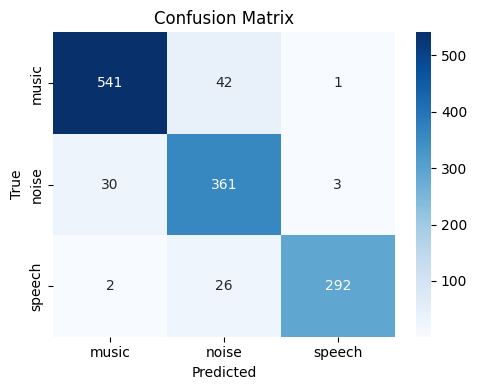

In [43]:
# ---------- 9. Test ----------
ckpt = torch.load("best.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"])
model.eval()
 
ys, ps = [], []
with torch.no_grad():
    for x, y in test_dl:
        ps += model(x.to(DEVICE)).argmax(1).cpu().tolist()
        ys += y.tolist()
 
present = sorted(set(ys) | set(ps))
print(classification_report(ys, ps, labels=present,
                            target_names=[CLASSES[i] for i in present], digits=4))
cm = confusion_matrix(ys, ps, labels=present)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[CLASSES[i] for i in present],
            yticklabels=[CLASSES[i] for i in present])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.tight_layout(); plt.show()